In [126]:
.libPaths()

[1] "/usr/local/lib/R/site-library" "/usr/local/lib/R/library"

## 1. Seurat using sctransform on patient 3

In [127]:
library(Seurat)
library(ggplot2)
library(sctransform)

In [128]:
patient3.data <- Read10X(data.dir = "/home/rstudio/run070/run070-nsclc-3_RSEC_MolsPerCell_MEX")
patient3 <- CreateSeuratObject(counts = patient3.data, project = "patient3", min.cells = 3, min.features = 200)

In [129]:
#QC #calculates the percentage of counts originating from a set of features #mitochondrial contamination
patient3[["percent.mt"]] <- PercentageFeatureSet(patient3, pattern = "^MT-")

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


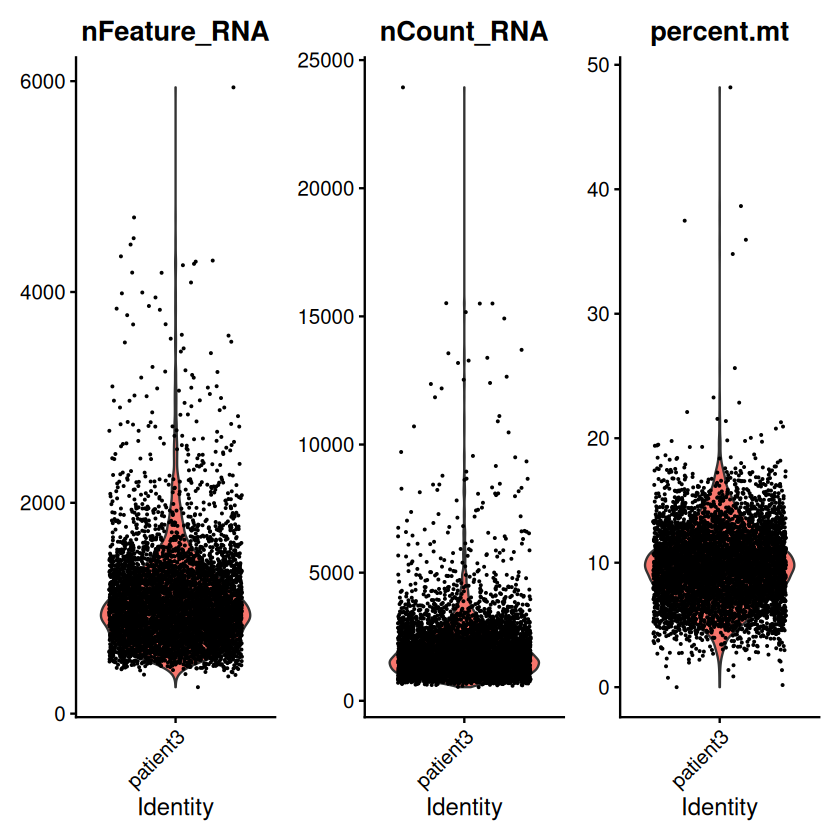

In [130]:
# Violin Plot
VlnPlot(patient3, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

In [131]:
# run sctransform
# this single command replaces NormalizeData(), ScaleData(), and FindVariableFeatures() #install glmGamPoi
patient3_transform <- SCTransform(patient3, verbose = FALSE) #No filtering based on mito. contamination

`vst.flavor` is set to 'v2' but could not find glmGamPoi installed.
Please install the glmGamPoi package for much faster estimation.
--------------------------------------------
install.packages('BiocManager')
BiocManager::install('glmGamPoi')
--------------------------------------------
Falling back to native (slower) implementation.


Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = co

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, m

In [132]:
patient3_transform <- subset(patient3_transform, subset = percent.mt < 10)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


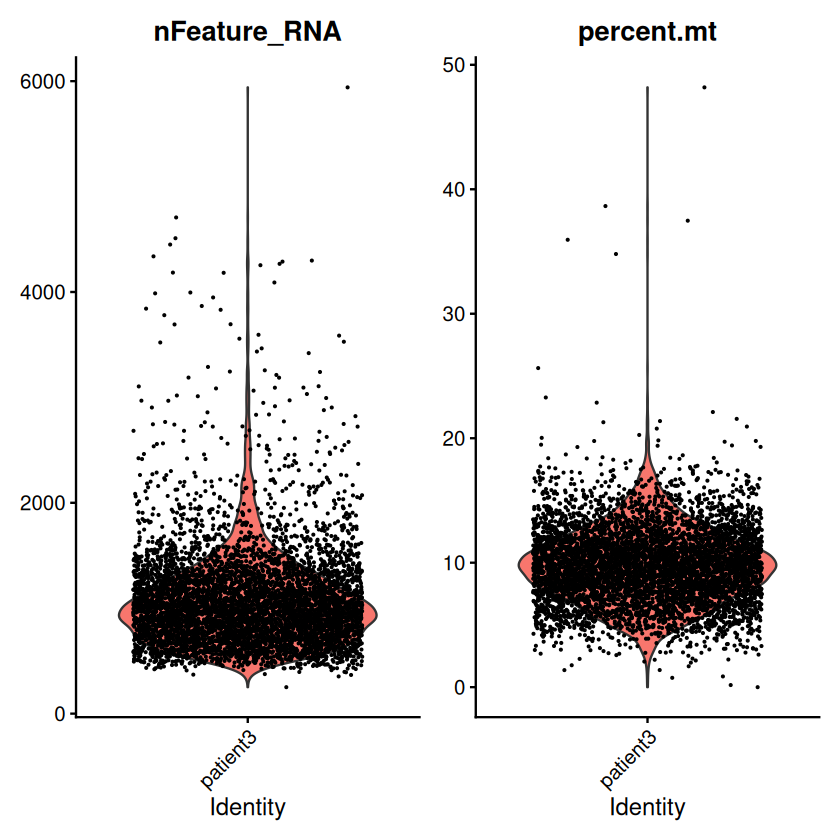

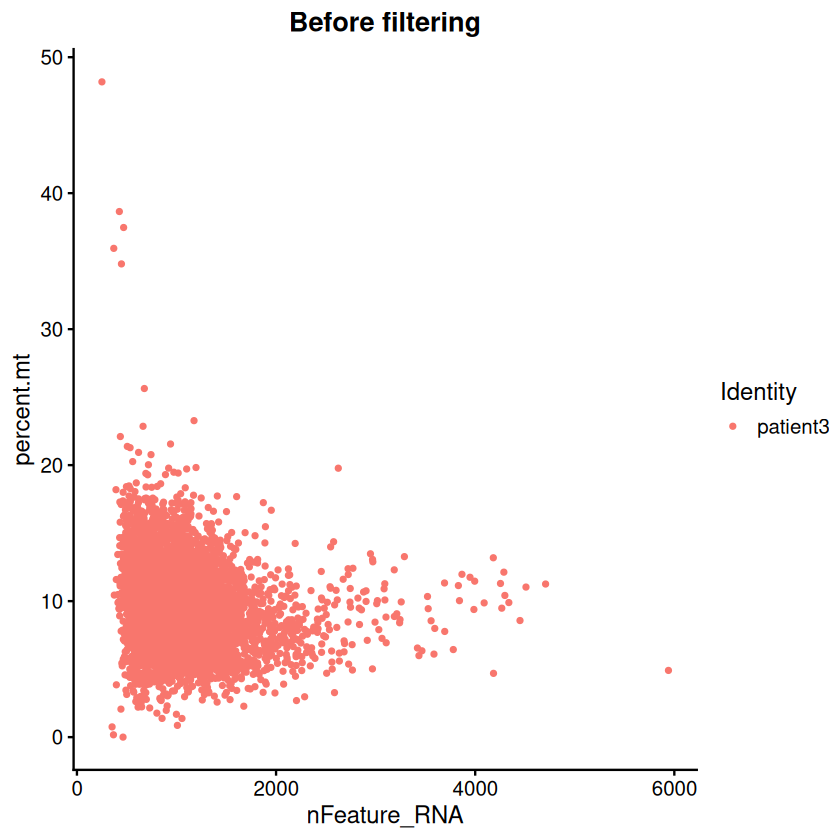

In [133]:
# before filtering
VlnPlot(patient3, features = c("nFeature_RNA", "percent.mt"), pt.size = 0.1)

FeatureScatter(patient3, feature1 = "nFeature_RNA", feature2 = "percent.mt") +
  ggtitle("Before filtering")

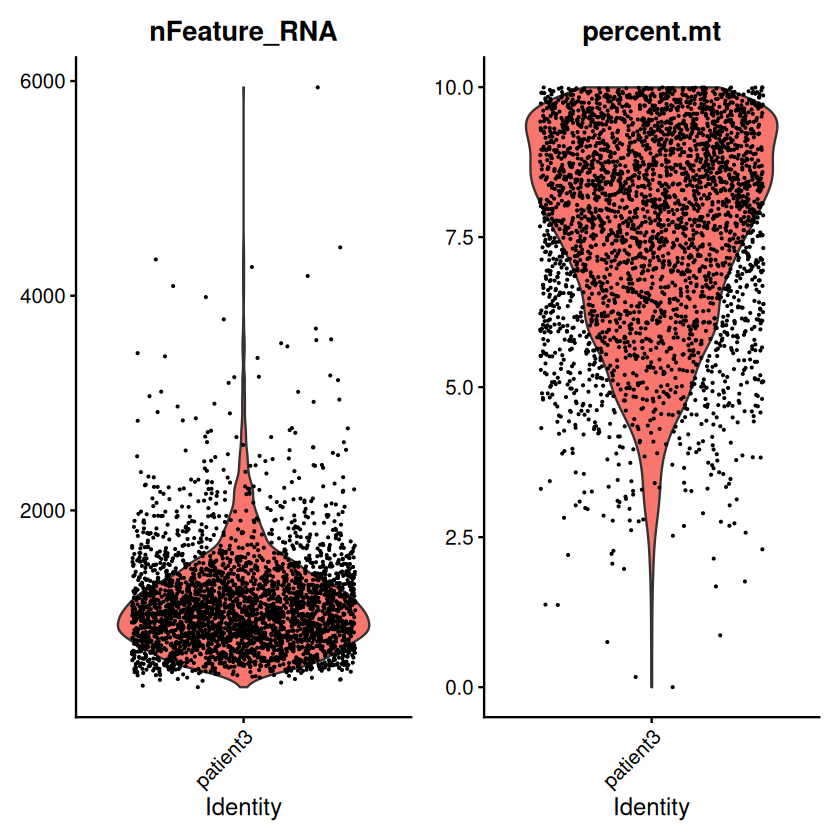

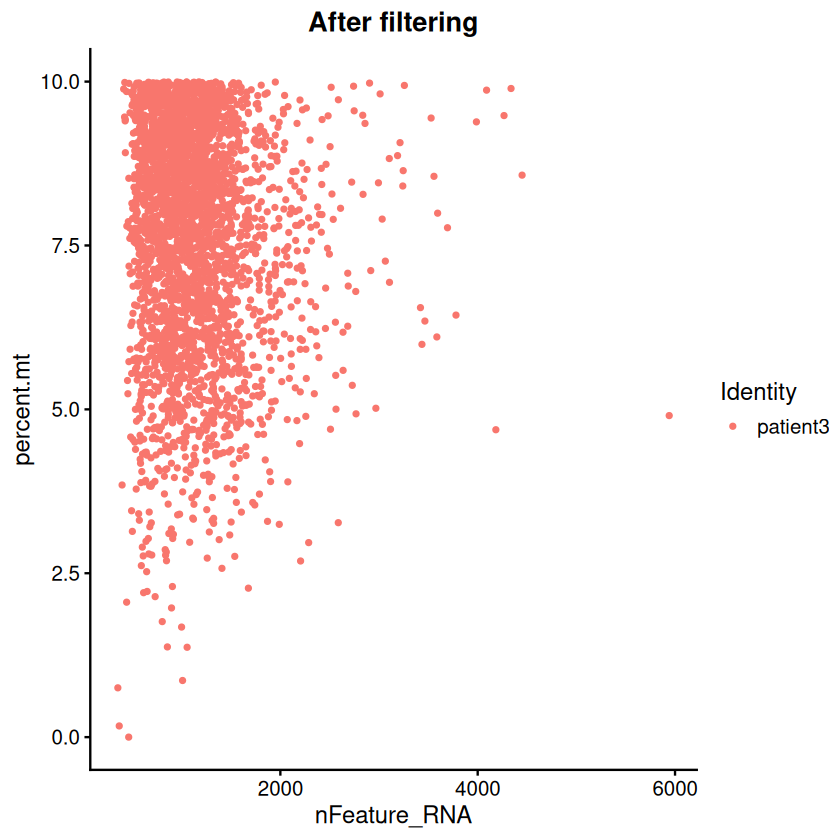

In [134]:
# after filtering
VlnPlot(patient3_transform, features = c("nFeature_RNA", "percent.mt"), pt.size = 0.1)

FeatureScatter(patient3_transform, feature1 = "nFeature_RNA", feature2 = "percent.mt") +
  ggtitle("After filtering")

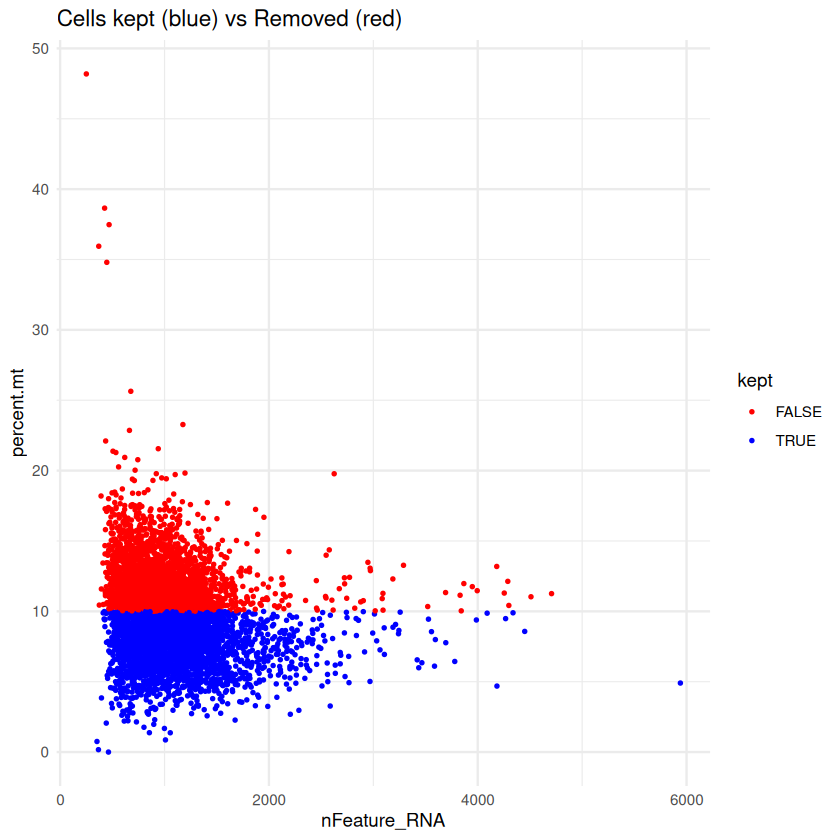

In [135]:
# Retained - Blue, Removed - Red
df <- FetchData(patient3, vars = c("nFeature_RNA", "percent.mt"))
df$kept <- rownames(df) %in% colnames(patient3_transform)

ggplot(df, aes(x = nFeature_RNA, y = percent.mt, color = kept)) +
  geom_point(size = 0.5) +
  scale_color_manual(values = c("red", "blue")) +
  theme_minimal() +
  labs(title = "Cells kept (blue) vs Removed (red)")

## 2. scRepertoire on patient 3

In [136]:
library(scRepertoire)
S1 <- read.delim("/home/rstudio/run070/run070-nsclc-3_VDJ_Dominant_Contigs_AIRR.tsv", sep = "\t", header = TRUE, stringsAsFactors = FALSE)

contig_list_1 <- list(S1)
contig_list_1 <- loadContigs(input = S1, 
                           format = "AIRR")

#converting columns in TCR data to character (string).
contig_list <- lapply(contig_list, function(df) {
  for (col in c("cdr3_nt", "cdr3", "chain", "barcode", "v_gene", "j_gene", "d_gene", "c_gene")) {
    if (col %in% names(df)) df[[col]] <- as.character(df[[col]])
  }
  df
})

In [137]:
data("contig_list")
#head(contig_list)
head(contig_list[[1]])

,barcode,is_cell,contig_id,high_confidence,length,chain,v_gene,d_gene,j_gene,c_gene,full_length,productive,cdr3,cdr3_nt,reads,umis,raw_clonotype_id,raw_consensus_id
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
1,AAACCTGAGTACGACG-1,True,AAACCTGAGTACGACG-1_contig_1,True,500,TRA,TRAV25,None,TRAJ20,TRAC,True,True,CGCSNDYKLSF,TGTGGGTGTTCTAACGACTACAAGCTCAGCTTT,8344,4,clonotype123,clonotype123_consensus_2
2,AAACCTGAGTACGACG-1,True,AAACCTGAGTACGACG-1_contig_2,True,478,TRB,TRBV5-1,None,TRBJ2-7,TRBC2,True,True,CASSLTDRTYEQYF,TGCGCCAGCAGCTTGACCGACAGGACCTACGAGCAGTACTTC,65390,38,clonotype123,clonotype123_consensus_1
4,AAACCTGCAACACGCC-1,True,AAACCTGCAACACGCC-1_contig_1,True,506,TRA,TRAV38-2/DV8,None,TRAJ52,TRAC,True,True,CAYRSAQAGGTSYGKLTF,TGTGCTTATAGGAGCGCGCAGGCTGGTGGTACTAGCTATGGAAAGCTGACATTT,18372,8,clonotype124,clonotype124_consensus_1
5,AAACCTGCAACACGCC-1,True,AAACCTGCAACACGCC-1_contig_2,True,470,TRB,TRBV10-3,None,TRBJ2-2,TRBC2,True,True,CAISEQGKGELFF,TGTGCCATCAGTGAACAGGGGAAAGGGGAGCTGTTTTTT,34054,9,clonotype124,clonotype124_consensus_2
6,AAACCTGCAGGCGATA-1,True,AAACCTGCAGGCGATA-1_contig_1,True,558,TRA,TRAV12-1,None,TRAJ9,TRAC,True,True,CVVSDNTGGFKTIF,TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT,5018,2,clonotype1,clonotype1_consensus_2
7,AAACCTGCAGGCGATA-1,True,AAACCTGCAGGCGATA-1_contig_2,True,505,TRB,TRBV9,None,TRBJ2-2,TRBC2,True,True,CASSVRRERANTGELFF,TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT,25110,11,clonotype1,clonotype1_consensus_1


In [138]:
combined.TCR_p3 <- combineTCR(
  contig_list_1,
  samples = c("P3_S1"),
  removeNA = TRUE,
  removeMulti = FALSE,
  filterMulti = FALSE
)

# output = a list of contig data frames that will be reduced to the reads associated with a single cell barcode. It will also combine the multiple reads into clone calls by either the nucleotide sequence (CTnt), amino acid sequence (CTaa), the VDJC gene sequence (CTgene), or the combination of the nucleotide and gene sequence (CTstrict).
head(combined.TCR_p3[[1]])

,barcode,sample,TCR1,cdr3_aa1,cdr3_nt1,TCR2,cdr3_aa2,cdr3_nt2,CTgene,CTnt,CTaa,CTstrict
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,P3_S1_10006345,P3_S1,TRAV35*01.TRAJ18*01.TRAC,CAGPDRGSTLGRLYF,TGTGCTGGACCCGACAGAGGCTCAACCCTGGGGAGGCTATACTTT,TRBV20-1*01.TRBD2*01.TRBJ2-1*01.TRBC2,CSARGLGGSYNEQFF,TGCAGTGCTAGAGGATTGGGGGGGTCCTACAATGAGCAGTTCTTC,TRAV35*01.TRAJ18*01.TRAC_TRBV20-1*01.TRBD2*01.TRBJ2-1*01.TRBC2,TGTGCTGGACCCGACAGAGGCTCAACCCTGGGGAGGCTATACTTT_TGCAGTGCTAGAGGATTGGGGGGGTCCTACAATGAGCAGTTCTTC,CAGPDRGSTLGRLYF_CSARGLGGSYNEQFF,TRAV35*01.TRAJ18*01.TRAC;TGTGCTGGACCCGACAGAGGCTCAACCCTGGGGAGGCTATACTTT_TRBV20-1*01.TRBD2*01.TRBJ2-1*01.TRBC2;TGCAGTGCTAGAGGATTGGGGGGGTCCTACAATGAGCAGTTCTTC
3,P3_S1_10007655,P3_S1,TRAV17*01.TRAJ4*01.TRAC,CATDLFSGGYNKLIF,TGTGCTACGGATCTCTTTTCTGGTGGCTACAATAAGCTGATTTTT,TRBV6-6*01.TRBD2*01.TRBJ2-7*01.TRBC2,CASSQAGEQYF,TGTGCCAGCAGCCAGGCGGGCGAGCAGTACTTC,TRAV17*01.TRAJ4*01.TRAC_TRBV6-6*01.TRBD2*01.TRBJ2-7*01.TRBC2,TGTGCTACGGATCTCTTTTCTGGTGGCTACAATAAGCTGATTTTT_TGTGCCAGCAGCCAGGCGGGCGAGCAGTACTTC,CATDLFSGGYNKLIF_CASSQAGEQYF,TRAV17*01.TRAJ4*01.TRAC;TGTGCTACGGATCTCTTTTCTGGTGGCTACAATAAGCTGATTTTT_TRBV6-6*01.TRBD2*01.TRBJ2-7*01.TRBC2;TGTGCCAGCAGCCAGGCGGGCGAGCAGTACTTC
5,P3_S1_10024172,P3_S1,TRAV12-1*01.TRAJ42*01.TRAC,CVVNLAYYGGSQGNLIF,TGTGTGGTGAACCTTGCTTATTATGGAGGAAGCCAAGGAAATCTCATCTTT,TRBV9*01.NA.TRBJ1-5*01.TRBC1,CASSPGPSQPQHF,TGTGCCAGCAGCCCAGGACCGAGTCAGCCCCAGCATTTT,TRAV12-1*01.TRAJ42*01.TRAC_TRBV9*01.NA.TRBJ1-5*01.TRBC1,TGTGTGGTGAACCTTGCTTATTATGGAGGAAGCCAAGGAAATCTCATCTTT_TGTGCCAGCAGCCCAGGACCGAGTCAGCCCCAGCATTTT,CVVNLAYYGGSQGNLIF_CASSPGPSQPQHF,TRAV12-1*01.TRAJ42*01.TRAC;TGTGTGGTGAACCTTGCTTATTATGGAGGAAGCCAAGGAAATCTCATCTTT_TRBV9*01.NA.TRBJ1-5*01.TRBC1;TGTGCCAGCAGCCCAGGACCGAGTCAGCCCCAGCATTTT
7,P3_S1_10069653,P3_S1,TRAV3*01.TRAJ34*01.NA;TRGV2*01.TRGJP1*01.NA,CAVRGSIGTDKLIF;CATWDGFGWFKIF,TGTGCTGTGAGAGGTTCAATAGGAACCGACAAGCTCATCTTT;TGTGCCACCTGGGACGGGTTCGGTTGGTTCAAGATATTT,TRDV3*01.TRDD3*01.TRDJ1*01.TRDC,CAFNRNWGIHSDKLIF,TGTGCCTTTAATCGAAACTGGGGGATACATTCCGATAAACTCATCTTT,TRAV3*01.TRAJ34*01.NA;TRGV2*01.TRGJP1*01.NA_TRDV3*01.TRDD3*01.TRDJ1*01.TRDC,TGTGCTGTGAGAGGTTCAATAGGAACCGACAAGCTCATCTTT;TGTGCCACCTGGGACGGGTTCGGTTGGTTCAAGATATTT_TGTGCCTTTAATCGAAACTGGGGGATACATTCCGATAAACTCATCTTT,CAVRGSIGTDKLIF;CATWDGFGWFKIF_CAFNRNWGIHSDKLIF,TRAV3*01.TRAJ34*01.NA;TRGV2*01.TRGJP1*01.NA;TGTGCTGTGAGAGGTTCAATAGGAACCGACAAGCTCATCTTT;TGTGCCACCTGGGACGGGTTCGGTTGGTTCAAGATATTT_TRDV3*01.TRDD3*01.TRDJ1*01.TRDC;TGTGCCTTTAATCGAAACTGGGGGATACATTCCGATAAACTCATCTTT
10,P3_S1_10075139,P3_S1,TRAV19*01.TRAJ6*01.TRAC,CALSGRSGGSYIPTF,TGTGCTCTGAGTGGTAGATCAGGAGGAAGCTACATACCTACATTT,TRBV7-9*03.NA.TRBJ1-1*01.TRBC1,CASSFADSTTEAFF,TGTGCCAGCAGCTTTGCCGATTCTACCACTGAAGCTTTCTTT,TRAV19*01.TRAJ6*01.TRAC_TRBV7-9*03.NA.TRBJ1-1*01.TRBC1,TGTGCTCTGAGTGGTAGATCAGGAGGAAGCTACATACCTACATTT_TGTGCCAGCAGCTTTGCCGATTCTACCACTGAAGCTTTCTTT,CALSGRSGGSYIPTF_CASSFADSTTEAFF,TRAV19*01.TRAJ6*01.TRAC;TGTGCTCTGAGTGGTAGATCAGGAGGAAGCTACATACCTACATTT_TRBV7-9*03.NA.TRBJ1-1*01.TRBC1;TGTGCCAGCAGCTTTGCCGATTCTACCACTGAAGCTTTCTTT
12,P3_S1_10088479,P3_S1,TRAV13-1*01.TRAJ54*01.TRAC,CAASMVGAQKLVF,TGTGCAGCAAGTATGGTTGGAGCCCAGAAGCTGGTATTT,TRBV28*01.TRBD1*01.TRBJ2-7*01.TRBC2,CASSLSLGASYEQYF,TGTGCCAGCAGTTTATCTTTGGGGGCCTCCTACGAGCAGTACTTC,TRAV13-1*01.TRAJ54*01.TRAC_TRBV28*01.TRBD1*01.TRBJ2-7*01.TRBC2,TGTGCAGCAAGTATGGTTGGAGCCCAGAAGCTGGTATTT_TGTGCCAGCAGTTTATCTTTGGGGGCCTCCTACGAGCAGTACTTC,CAASMVGAQKLVF_CASSLSLGASYEQYF,TRAV13-1*01.TRAJ54*01.TRAC;TGTGCAGCAAGTATGGTTGGAGCCCAGAAGCTGGTATTT_TRBV28*01.TRBD1*01.TRBJ2-7*01.TRBC2;TGTGCCAGCAGTTTATCTTTGGGGGCCTCCTACGAGCAGTACTTC


### Visualization

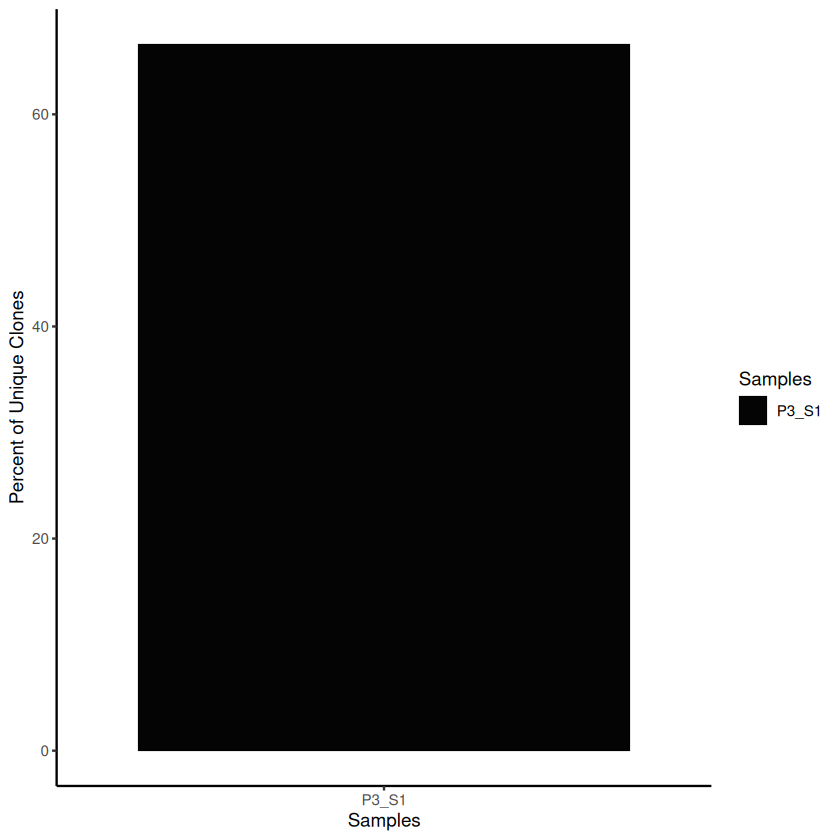

In [139]:
# total or relative numbers of unique clones.
clonalQuant(combined.TCR_p3, 
            cloneCall="strict", 
            chain = "both", 
            scale = TRUE)

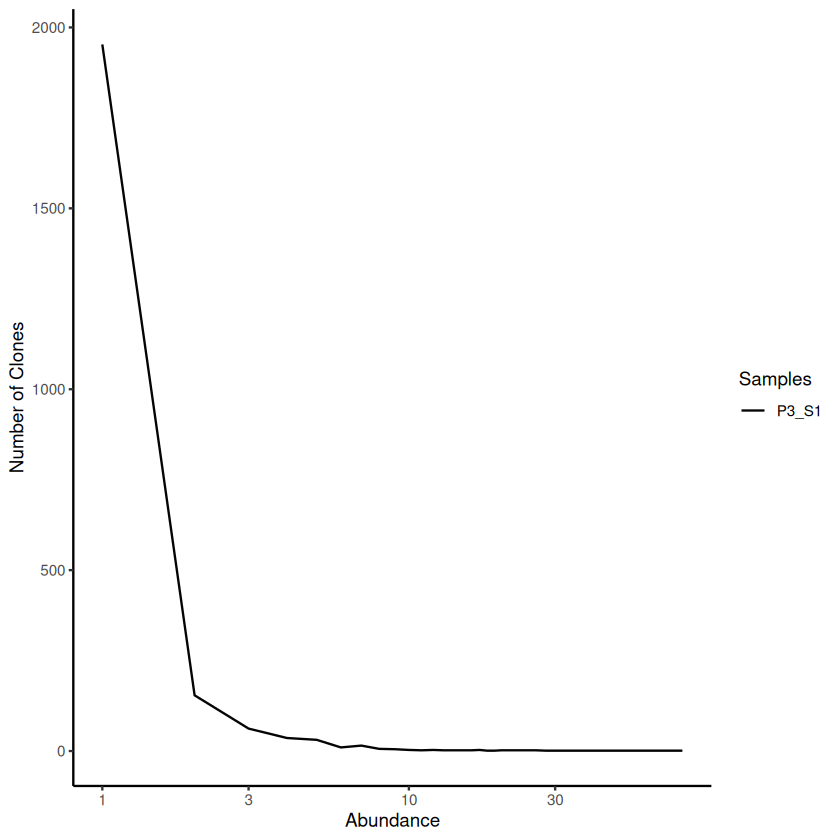

In [140]:
# a total number of clones by the number of instances within the sample or run
clonalAbundance(combined.TCR_p3, 
                cloneCall = "gene", 
                scale = FALSE)

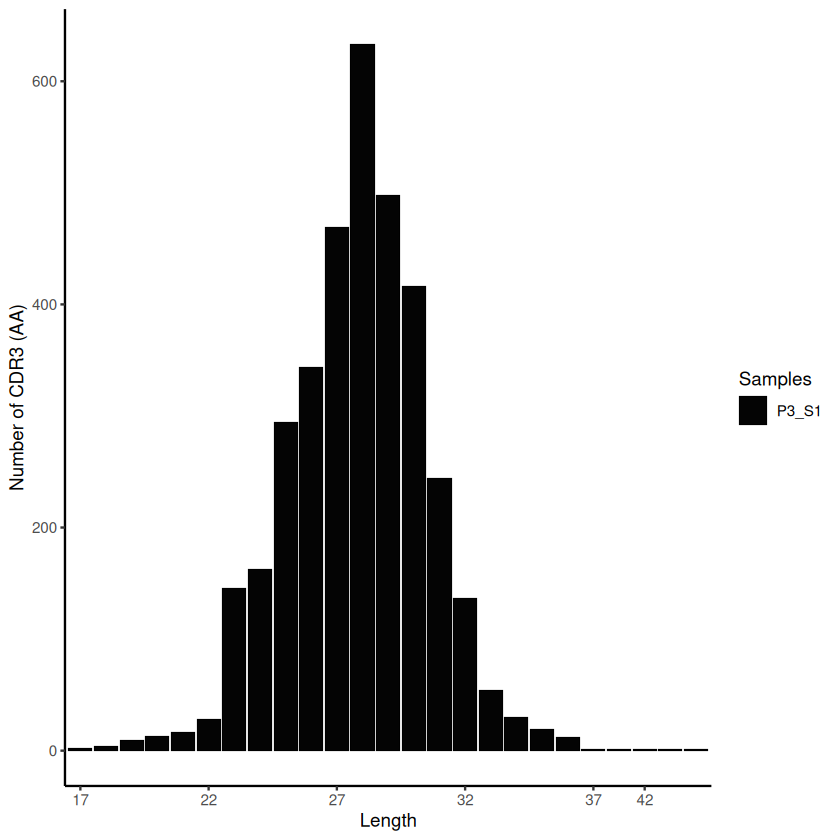

In [141]:
clonalLength(combined.TCR_p3, 
             cloneCall="aa", 
             chain = "both") 

## 3. Seurat using sctransform on patient 4

In [142]:
patient4.data <- Read10X(data.dir = "/home/rstudio/run071/run071_RSEC_MolsPerCell_MEX")
patient4 <- CreateSeuratObject(counts = patient4.data, project = "patient4", min.cells = 3, min.features = 200)

In [143]:
#QC #calculates the percentage of counts originating from a set of features #mitochondrial contamination
patient4[["percent.mt"]] <- PercentageFeatureSet(patient4, pattern = "^MT-")

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


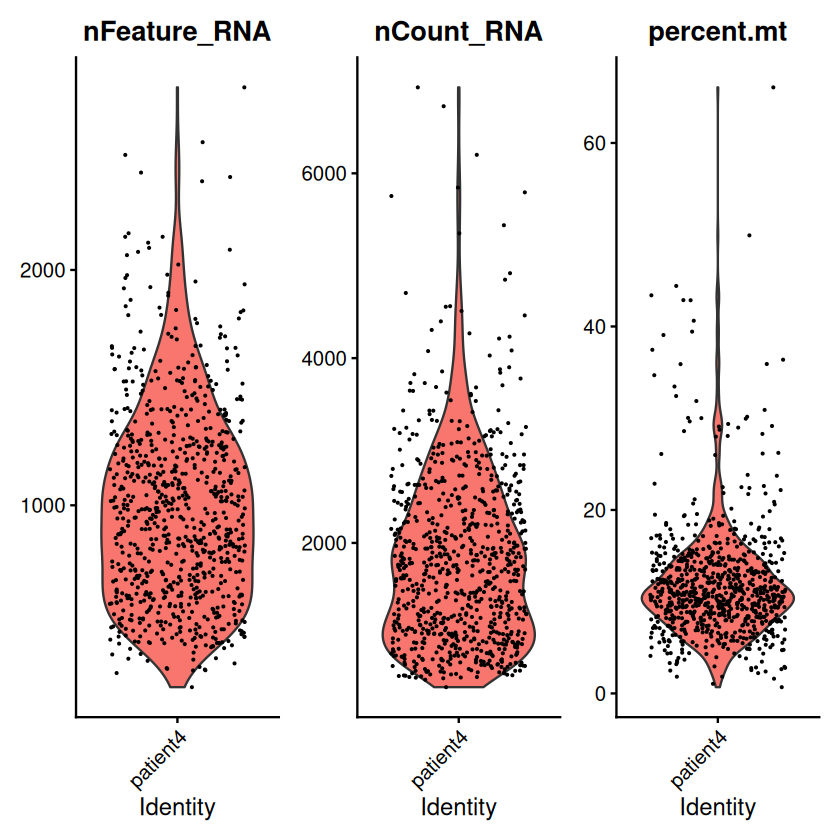

In [144]:
# Violin Plot
VlnPlot(patient4, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

In [145]:
# run sctransform
# this single command replaces NormalizeData(), ScaleData(), and FindVariableFeatures() #install glmGamPoi
patient4_transform <- SCTransform(patient4, verbose = FALSE) #No filtering based on mito. contamination

`vst.flavor` is set to 'v2' but could not find glmGamPoi installed.
Please install the glmGamPoi package for much faster estimation.
--------------------------------------------
install.packages('BiocManager')
BiocManager::install('glmGamPoi')
--------------------------------------------
Falling back to native (slower) implementation.


Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = co

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, m

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


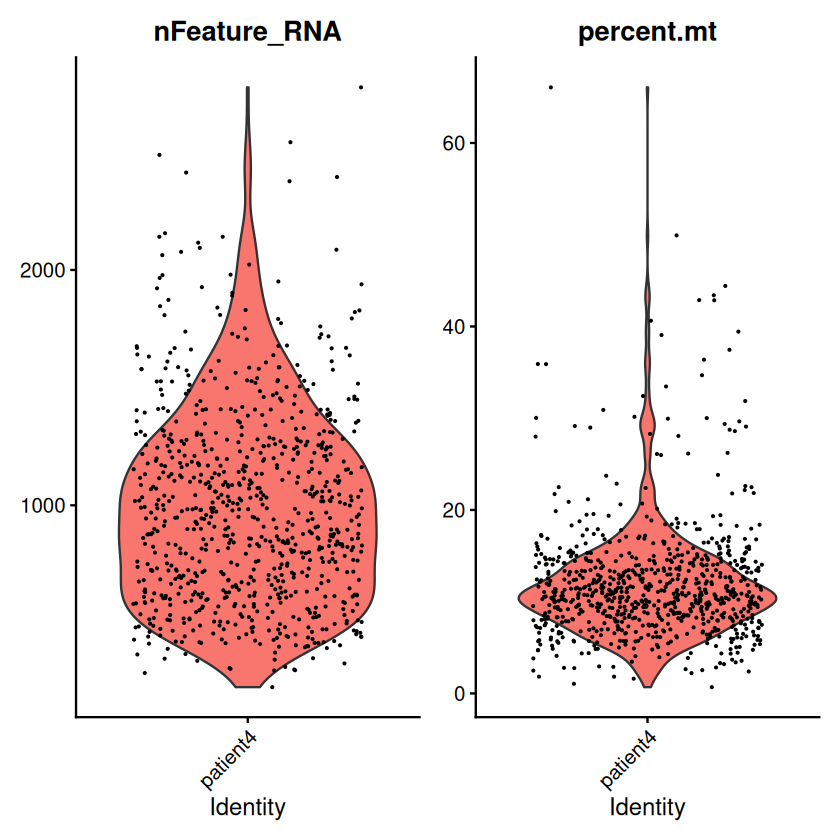

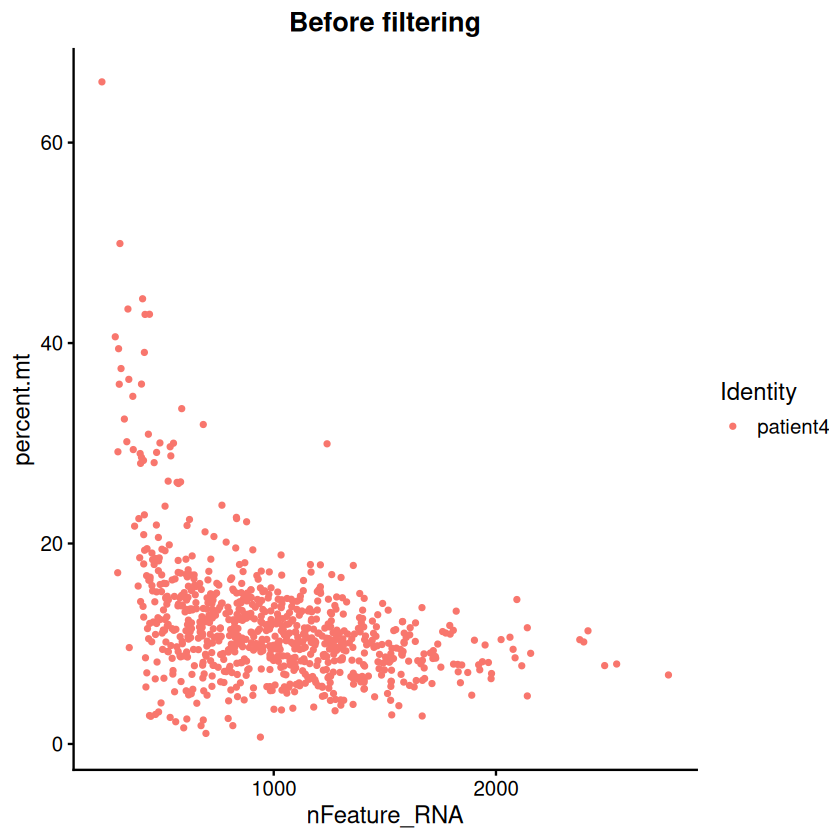

In [146]:
# before filtering
VlnPlot(patient4, features = c("nFeature_RNA", "percent.mt"), pt.size = 0.1)

FeatureScatter(patient4, feature1 = "nFeature_RNA", feature2 = "percent.mt") +
  ggtitle("Before filtering")

In [147]:
patient4_transform <- subset(patient4_transform, subset = percent.mt < 10)

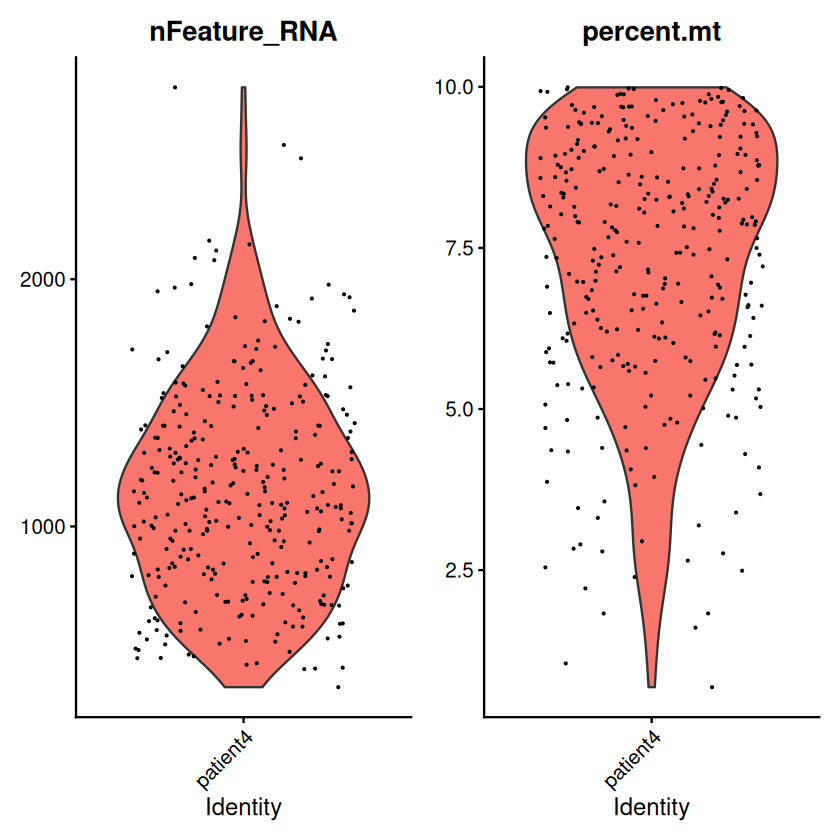

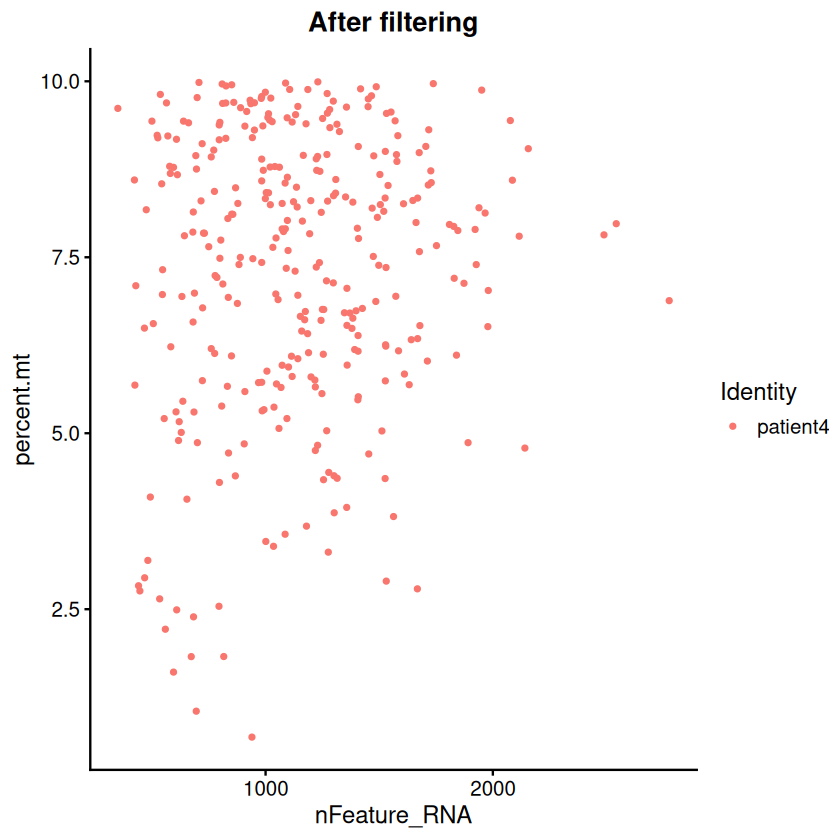

In [148]:
# after filtering
VlnPlot(patient4_transform, features = c("nFeature_RNA", "percent.mt"), pt.size = 0.1)

FeatureScatter(patient4_transform, feature1 = "nFeature_RNA", feature2 = "percent.mt") +
  ggtitle("After filtering")

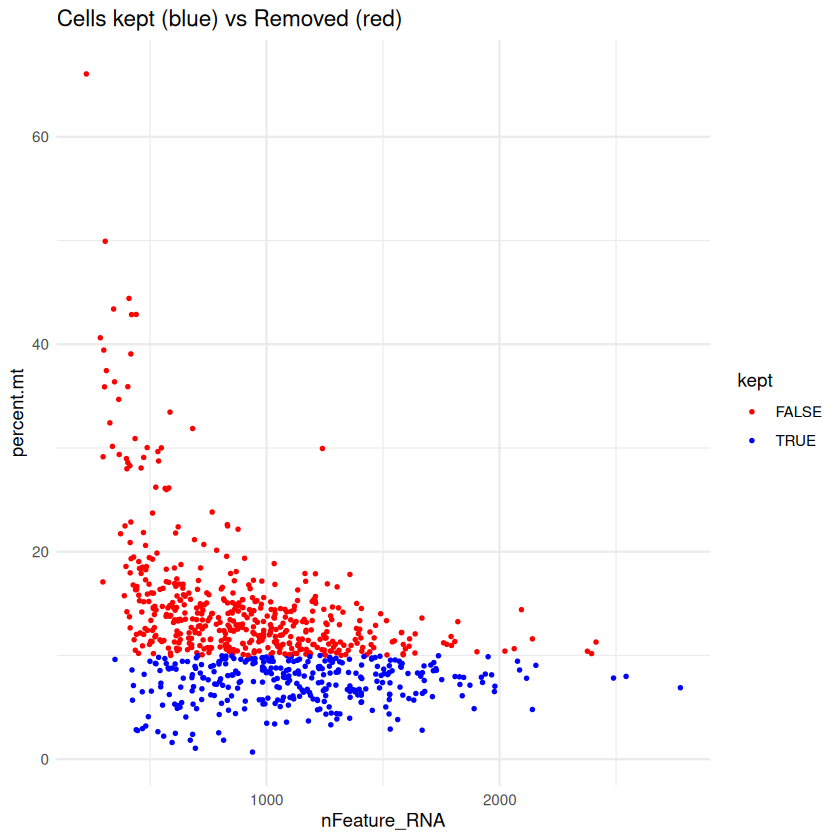

In [149]:
# Retained - Blue, Removed - Red
df <- FetchData(patient4, vars = c("nFeature_RNA", "percent.mt"))
df$kept <- rownames(df) %in% colnames(patient4_transform)

ggplot(df, aes(x = nFeature_RNA, y = percent.mt, color = kept)) +
  geom_point(size = 0.5) +
  scale_color_manual(values = c("red", "blue")) +
  theme_minimal() +
  labs(title = "Cells kept (blue) vs Removed (red)")

## 4. scRepertoire on patient 4

In [150]:
library(scRepertoire)
#S1 <- read.delim("/home/rstudio/run071-nsclc-4_VDJ_Dominant_Contigs_AIRR.tsv", sep = "\t", header = TRUE, stringsAsFactors = FALSE)

#contig_list <- list(S1)
#contig.list <- loadContigs(input = S1, 
#                           format = "AIRR")

In [151]:
S2 <- read.delim("/home/rstudio/run071-nsclc-4_VDJ_Dominant_Contigs_AIRR.tsv", sep = "\t", header = TRUE, stringsAsFactors = FALSE)

contig_list_2 <- loadContigs(input = S2, format = "AIRR")

#converting columns in TCR data to character (string).
contig_list_2 <- lapply(contig_list, function(df) {
  for (col in c("cdr3_nt", "cdr3", "chain", "barcode", "v_gene", "j_gene", "d_gene", "c_gene")) {
    if (col %in% names(df)) df[[col]] <- as.character(df[[col]])
  }
  df
})

In [152]:
#data("contig_list")
#head(contig_list)
head(contig_list_2[[1]])

,barcode,is_cell,contig_id,high_confidence,length,chain,v_gene,d_gene,j_gene,c_gene,full_length,productive,cdr3,cdr3_nt,reads,umis,raw_clonotype_id,raw_consensus_id
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
1,AAACCTGAGTACGACG-1,True,AAACCTGAGTACGACG-1_contig_1,True,500,TRA,TRAV25,None,TRAJ20,TRAC,True,True,CGCSNDYKLSF,TGTGGGTGTTCTAACGACTACAAGCTCAGCTTT,8344,4,clonotype123,clonotype123_consensus_2
2,AAACCTGAGTACGACG-1,True,AAACCTGAGTACGACG-1_contig_2,True,478,TRB,TRBV5-1,None,TRBJ2-7,TRBC2,True,True,CASSLTDRTYEQYF,TGCGCCAGCAGCTTGACCGACAGGACCTACGAGCAGTACTTC,65390,38,clonotype123,clonotype123_consensus_1
4,AAACCTGCAACACGCC-1,True,AAACCTGCAACACGCC-1_contig_1,True,506,TRA,TRAV38-2/DV8,None,TRAJ52,TRAC,True,True,CAYRSAQAGGTSYGKLTF,TGTGCTTATAGGAGCGCGCAGGCTGGTGGTACTAGCTATGGAAAGCTGACATTT,18372,8,clonotype124,clonotype124_consensus_1
5,AAACCTGCAACACGCC-1,True,AAACCTGCAACACGCC-1_contig_2,True,470,TRB,TRBV10-3,None,TRBJ2-2,TRBC2,True,True,CAISEQGKGELFF,TGTGCCATCAGTGAACAGGGGAAAGGGGAGCTGTTTTTT,34054,9,clonotype124,clonotype124_consensus_2
6,AAACCTGCAGGCGATA-1,True,AAACCTGCAGGCGATA-1_contig_1,True,558,TRA,TRAV12-1,None,TRAJ9,TRAC,True,True,CVVSDNTGGFKTIF,TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT,5018,2,clonotype1,clonotype1_consensus_2
7,AAACCTGCAGGCGATA-1,True,AAACCTGCAGGCGATA-1_contig_2,True,505,TRB,TRBV9,None,TRBJ2-2,TRBC2,True,True,CASSVRRERANTGELFF,TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT,25110,11,clonotype1,clonotype1_consensus_1


In [153]:
combined.TCR_p4 <- combineTCR(
  contig_list_2,
  samples = c("P4_S1"),
  removeNA = TRUE,
  removeMulti = FALSE,
  filterMulti = FALSE
)

# output = a list of contig data frames that wilcox.testl be reduced to the reads associated with a single cell barcode. It will also combine the multiple reads into clone calls by either the nucleotide sequence (CTnt), amino acid sequence (CTaa), the VDJC gene sequence (CTgene), or the combination of the nucleotide and gene sequence (CTstrict).
head(combined.TCR_p4[[1]])

,barcode,sample,TCR1,cdr3_aa1,cdr3_nt1,TCR2,cdr3_aa2,cdr3_nt2,CTgene,CTnt,CTaa,CTstrict
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,P4_S1_AAACCTGAGTACGACG-1,P4_S1,TRAV25.TRAJ20.TRAC,CGCSNDYKLSF,TGTGGGTGTTCTAACGACTACAAGCTCAGCTTT,TRBV5-1.None.TRBJ2-7.TRBC2,CASSLTDRTYEQYF,TGCGCCAGCAGCTTGACCGACAGGACCTACGAGCAGTACTTC,TRAV25.TRAJ20.TRAC_TRBV5-1.None.TRBJ2-7.TRBC2,TGTGGGTGTTCTAACGACTACAAGCTCAGCTTT_TGCGCCAGCAGCTTGACCGACAGGACCTACGAGCAGTACTTC,CGCSNDYKLSF_CASSLTDRTYEQYF,TRAV25.TRAJ20.TRAC;TGTGGGTGTTCTAACGACTACAAGCTCAGCTTT_TRBV5-1.None.TRBJ2-7.TRBC2;TGCGCCAGCAGCTTGACCGACAGGACCTACGAGCAGTACTTC
3,P4_S1_AAACCTGCAACACGCC-1,P4_S1,TRAV38-2/DV8.TRAJ52.TRAC,CAYRSAQAGGTSYGKLTF,TGTGCTTATAGGAGCGCGCAGGCTGGTGGTACTAGCTATGGAAAGCTGACATTT,TRBV10-3.None.TRBJ2-2.TRBC2,CAISEQGKGELFF,TGTGCCATCAGTGAACAGGGGAAAGGGGAGCTGTTTTTT,TRAV38-2/DV8.TRAJ52.TRAC_TRBV10-3.None.TRBJ2-2.TRBC2,TGTGCTTATAGGAGCGCGCAGGCTGGTGGTACTAGCTATGGAAAGCTGACATTT_TGTGCCATCAGTGAACAGGGGAAAGGGGAGCTGTTTTTT,CAYRSAQAGGTSYGKLTF_CAISEQGKGELFF,TRAV38-2/DV8.TRAJ52.TRAC;TGTGCTTATAGGAGCGCGCAGGCTGGTGGTACTAGCTATGGAAAGCTGACATTT_TRBV10-3.None.TRBJ2-2.TRBC2;TGTGCCATCAGTGAACAGGGGAAAGGGGAGCTGTTTTTT
5,P4_S1_AAACCTGCAGGCGATA-1,P4_S1,TRAV12-1.TRAJ9.TRAC,CVVSDNTGGFKTIF,TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT,TRBV9.None.TRBJ2-2.TRBC2,CASSVRRERANTGELFF,TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT,TRAV12-1.TRAJ9.TRAC_TRBV9.None.TRBJ2-2.TRBC2,TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT_TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT,CVVSDNTGGFKTIF_CASSVRRERANTGELFF,TRAV12-1.TRAJ9.TRAC;TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT_TRBV9.None.TRBJ2-2.TRBC2;TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT
7,P4_S1_AAACCTGCATGAGCGA-1,P4_S1,TRAV12-1.TRAJ9.TRAC,CVVSDNTGGFKTIF,TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT,TRBV9.None.TRBJ2-2.TRBC2,CASSVRRERANTGELFF,TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT,TRAV12-1.TRAJ9.TRAC_TRBV9.None.TRBJ2-2.TRBC2,TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT_TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT,CVVSDNTGGFKTIF_CASSVRRERANTGELFF,TRAV12-1.TRAJ9.TRAC;TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT_TRBV9.None.TRBJ2-2.TRBC2;TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT
10,P4_S1_AAACGGGAGCGTTTAC-1,P4_S1,TRAV12-1.TRAJ9.TRAC,CVVSDNTGGFKTIF,TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT,TRBV9.None.TRBJ2-2.TRBC2,CASSVRRERANTGELFF,TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT,TRAV12-1.TRAJ9.TRAC_TRBV9.None.TRBJ2-2.TRBC2,TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT_TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT,CVVSDNTGGFKTIF_CASSVRRERANTGELFF,TRAV12-1.TRAJ9.TRAC;TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT_TRBV9.None.TRBJ2-2.TRBC2;TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT
12,P4_S1_AAACGGGAGGGCACTA-1,P4_S1,TRAV12-1.TRAJ9.TRAC,CVVSDNTGGFKTIF,TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT,TRBV9.None.TRBJ2-2.TRBC2,CASSVRRERANTGELFF,TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT,TRAV12-1.TRAJ9.TRAC_TRBV9.None.TRBJ2-2.TRBC2,TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT_TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT,CVVSDNTGGFKTIF_CASSVRRERANTGELFF,TRAV12-1.TRAJ9.TRAC;TGTGTGGTCTCCGATAATACTGGAGGCTTCAAAACTATCTTT_TRBV9.None.TRBJ2-2.TRBC2;TGTGCCAGCAGCGTAAGGAGGGAAAGGGCGAACACCGGGGAGCTGTTTTTT


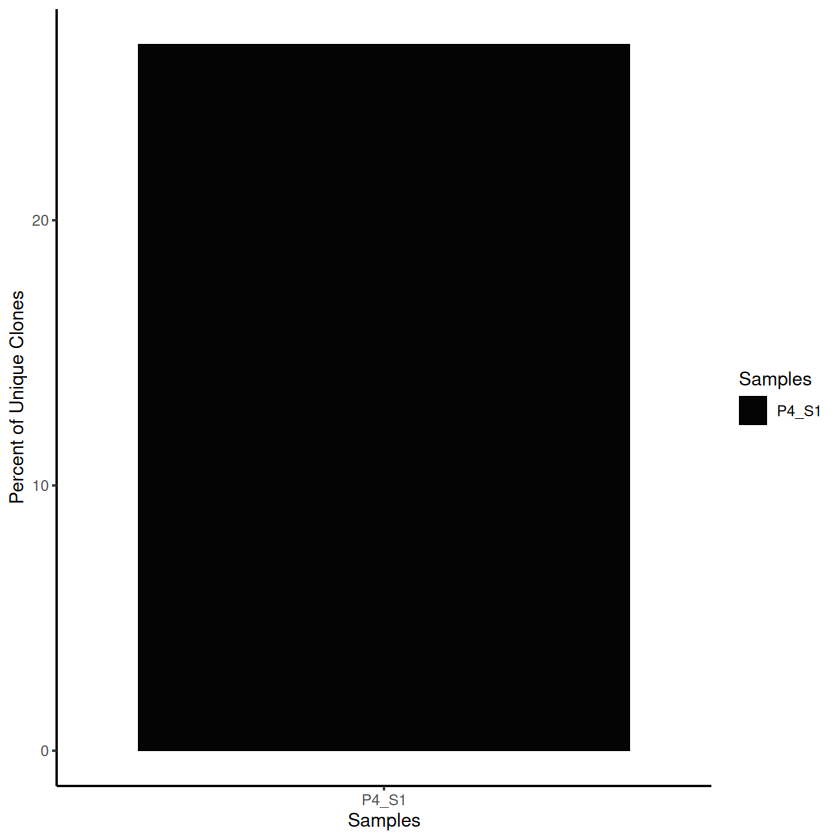

In [154]:
# total or relative numbers of unique clones.
clonalQuant(combined.TCR_p4, 
            cloneCall="strict", 
            chain = "both", 
            scale = TRUE)

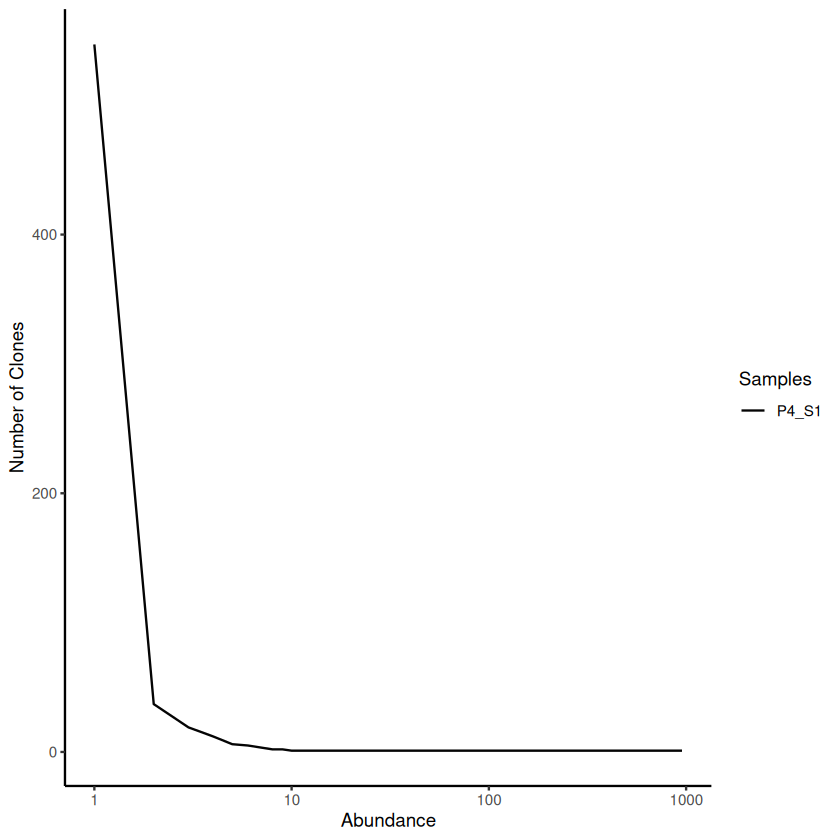

In [155]:
# a total number of clones by the number of instances within the sample or run
clonalAbundance(combined.TCR_p4, 
                cloneCall = "gene", 
                scale = FALSE)

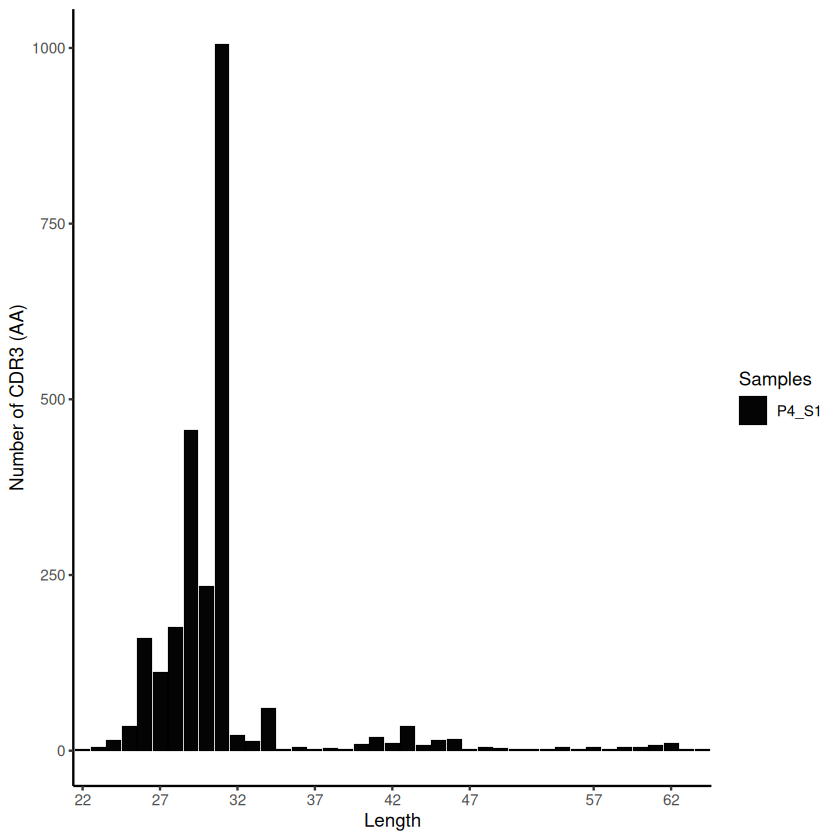

In [156]:
clonalLength(combined.TCR_p4, 
             cloneCall="aa", 
             chain = "both") 

In [157]:
sapply(contig_list_1, nrow)
sapply(contig_list_2, nrow)

[1] 8871

P17B  P17L  P18B  P18L  P19B  P19L  P20B  P20L 
 5504  5304  3005  2467 15003  5011 18513   347

## 5. Seurat using sctransform and RPCA integration on patients 3 and 4

In [158]:
# load in the pbmc systematic comparative analysis dataset
#obj <- LoadData("pbmcsca")
#obj <- subset(obj, nFeature_RNA > 1000)
#obj <- RunAzimuth(obj, reference = "pbmcref")
# currently, the object has two layers in the RNA assay: counts, and data
#obj


### Using integratelayers()

In [159]:
merged_seurat <- merge(patient3_transform, patient4_transform)

In [160]:
merged_seurat <- SCTransform(merged_seurat, verbose = FALSE)

`vst.flavor` is set to 'v2' but could not find glmGamPoi installed.
Please install the glmGamPoi package for much faster estimation.
--------------------------------------------
install.packages('BiocManager')
BiocManager::install('glmGamPoi')
--------------------------------------------
Falling back to native (slower) implementation.


Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = co

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in sqrt(1/i):
“N

In [161]:
merged_seurat <- RunPCA(merged_seurat, npcs = 35)

Warning message in PrepDR(object = object, features = features, verbose = verbose):
“The following 49 features requested have not been scaled (running reduction without them): CXCL8, FCER1G, KIR2DL1, MARCKS, KRT1, RRM2, IL1B, LYZ, CXCL3, ZBTB16, MTX2, KIR2DS4, MAFB, KLRC2, CCNA2, KRT72, ADAM23, PRKCH-AS1, LINC01215, HBA1, GCNT4, SLC41A2, CYBB, ZFY, P2RY14, ADM, SUSD4, ENSG00000289826, ZBED3, ZNF184, MS4A1, CCDC122, CCR4, NCAPG, SMIM43, USP9Y, LGR4, FOXP3, GRPEL2-AS1, RRAGC-DT, ICA1, DDX3Y, APOLD1, IFIT1, USP46, UTY, CHI3L2, XIST, TXLNGY”
PC_ 1 
Positive:  HSPA1A, DUSP4, CXCL13, HLA-DRB1, CCL5, CD74, HSP90AA1, RBPJ, RGS1, PMAIP1 
	   NKG7, GZMB, PRDM1, MYO7A, CRTAM, HSPA1B, HLA-DRA, ITGAE, CBLB, CCL4 
	   VCAM1, TUBB, TNFRSF9, BHLHE40, KRT86, SNX9, HMGN2, HMGB2, SAMSN1, IKZF3 
Negative:  FTH1, EEF1A1, IL7R, PABPC1, RPL34, RPS18, RPS6, TPT1, SELL, RPS12 
	   ANXA1, KLF2, RPS8, RPL3, RPL32, RPS27, RPS3A, RPL21, RPS13, SESN3 
	   RPS29, RPL39, RPL13A, RPS20, RPS23, LNCRNA-IUR, RPS2, RPL10,

In [162]:
merged_seurat

An object of class Seurat 
42872 features across 3483 samples within 2 assays 
Active assay: SCT (18998 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 1 dimensional reduction calculated: pca

In [163]:
#print(class(merged_seurat))
#print(names(Assays(merged_seurat)))

In [164]:
#print(merged_seurat[["RNA"]])
#print(merged_seurat[["SCT"]])

In [165]:
# PCA was run on SCT, not RNA

In [166]:
merged_seurat <- FindVariableFeatures(merged_seurat, assay = "RNA")

Finding variable features for layer counts.patient3

Finding variable features for layer counts.patient4

Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -2.2082”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.30103”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  1.651e-16”


In [167]:
merged_seurat <- NormalizeData(merged_seurat, assay = "RNA")

Normalizing layer: counts.patient3

Normalizing layer: counts.patient4



In [168]:
merged_seurat <- ScaleData(merged_seurat, assay = "RNA")

Centering and scaling data matrix



In [169]:
DefaultAssay(merged_seurat) <- "RNA"

In [170]:
merged_seurat <- RunPCA(merged_seurat, assay = "RNA", reduction.name = "pca.rna")

PC_ 1 
Positive:  TYMS, MKI67, RRM2, DUSP4, TOP2A, HLA-DRB1, NCAPG, STMN1, CXCL13, CENPU 
	   ASPM, TUBB, HLA-DRA, KIF11, TPX2, CCNA2, UBE2C, RBPJ, CDK1, MYO7A 
	   GZMB, CDKN3, HMGB2, BIRC5, TMPO, HSPA1A, CDCA5, KIF18B, CD74, ITGAE 
Negative:  IL7R, KLF2, SELL, PABPC1, SORL1, FTH1, ANXA1, SATB1, TCF7, SESN3 
	   LNCRNA-IUR, S1PR1, YBX3, RPS2, SNED1, RPS18, FOS, ZBTB16, GPR183, IRS2 
	   KRT1, RNF130, BACH2, TC2N, ACTN1, MBP, ABLIM1, GIMAP7, RORA-AS1, NR3C2 
PC_ 2 
Positive:  CCL5, DUSP4, MYO7A, NKG7, TNFRSF9, RGS1, CXCL13, HSPA1A, AKAP5, ITGAE 
	   PRDM1, LAYN, HLA-DRB1, RBPJ, GZMB, PRF1, KRT86, ETV1, VCAM1, ADGRG1 
	   CTLA4, HAVCR2, SNX9, KLRD1, DUSP5, SAMSN1, RDH10, GOLIM4, ENSG00000287347, CRTAM 
Negative:  RRM2, TOP2A, MKI67, NCAPG, TUBB, TYMS, IL7R, CDCA5, UBE2C, KLF2 
	   STMN1, SELL, CDK1, PABPC1, FTH1, KIF18B, KIF11, BIRC5, ASPM, ZWINT 
	   CENPU, CDKN3, TUBA1B, ASF1B, PRR11, PCLAF, UHRF1, KIF2C, CKAP2L, ZNF367 
PC_ 3 
Positive:  SNX9, SESN3, LNCRNA-IUR, FKBP5, PDE3B, SELL, C

In [171]:
merged_seurat <- IntegrateLayers(
  object = merged_seurat,
  method = RPCAIntegration,
  orig.reduction = "pca.rna",
  new.reduction = "integrated.rpca",
  verbose = TRUE,
  layers = c("counts.patient3", "counts.patient4"),
  assay = "RNA"
)

Computing within dataset neighborhoods

Finding all pairwise anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 237 anchors

Merging dataset 2 into 1

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data



In [172]:
#str(merged_seurat[["RNA"]])

### integratedata() - integration method CCA

In [173]:
seurat_list <- list(patient3_transform, patient4_transform)

In [174]:
seurat_list <- lapply(seurat_list, function(x) {
  x <- NormalizeData(x)
  x <- FindVariableFeatures(x, selection.method = "vst", nfeatures = 3000)
})

In [175]:
features <- SelectIntegrationFeatures(object.list = seurat_list)
#features <- SelectIntegrationFeatures(object.list = seurat_list, nfeatures = 3000)

In [176]:
anchors <- FindIntegrationAnchors(
  object.list = seurat_list,
  anchor.features = features,
  dims = 1:30,
  k.anchor = 5,
  reference = c(1, 2)
)

Scaling features for provided objects

Finding anchors between all query and reference datasets

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 1610 anchors

Filtering anchors

	Retained 1421 anchors



In [177]:
integrated_seurat <- IntegrateData(
  anchorset = anchors,
  dims = 1:30,
  k.weight = 100
)

Merging dataset 2 into 1

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Warning message:
“Layer counts isn't present in the assay object; returning NULL”


In [178]:
integrated_seurat

An object of class Seurat 
47197 features across 3483 samples within 3 assays 
Active assay: integrated (2000 features, 2000 variable features)
 1 layer present: data
 2 other assays present: RNA, SCT

In [179]:
#DefaultAssay(integrated_seurat) <- "integrated"

In [180]:
integrated_seurat <- ScaleData(integrated_seurat)
integrated_seurat <- RunPCA(integrated_seurat, npcs = 30)
integrated_seurat <- RunUMAP(integrated_seurat, dims = 1:30)
integrated_seurat <- FindNeighbors(integrated_seurat, dims = 1:30)
integrated_seurat <- FindClusters(integrated_seurat, resolution = 0.5)

Centering and scaling data matrix

PC_ 1 
Positive:  EEF1A1, IL7R, RPL34, TPT1, PABPC1, RPS6, RPS29, RPS27, FTH1, RPS12 
	   RPL39, RPL3, RPL21, RPS13, KLF2, RPS3A, SELL, RPL10, RPL32, RPL27A 
	   RPS2, RPS8, RPS4X, RPS3, RPS18, RPLP2, SORL1, RPL38, ANXA1, RPL13 
Negative:  DUSP4, HLA-DRB1, CXCL13, MYO7A, CCL5, RBPJ, GZMB, HSPA1A, ITGAE, NKG7 
	   PRDM1, HAVCR2, ENTPD1, CTLA4, VCAM1, TOX, RGS1, CBLB, TNFRSF9, IKZF3 
	   PMAIP1, CD74, HLA-DRA, ADGRG1, HLA-DRB6, APOBEC3C, LYST, LAYN, AKAP5, GOLIM4 
PC_ 2 
Positive:  HLA-B, MT-ND1, MT-ATP6, MT-CO1, MT-CO2, MT-ND4, ACTB, MT-ND2, MT-CYB, TMSB4X 
	   HSP90AA1, MT-CO3, CXCR4, VIM, RRM2, CD74, TOP2A, JUND, MKI67, STMN1 
	   TYMS, HLA-DRB1, SRGN, MT-ND5, DUSP4, TUBA1B, HSPA1A, ZFP36L2, ZFP36, BTG1 
Negative:  SESN3, ENSG00000266049, BACH2, ABLIM1, LINC-PINT, N4BP2L2, SMCHD1, STAT4, SNED1, CCR7 
	   LEF1, CAMK4, SELL, PITPNC1, LNCRNA-IUR, USP15, GPCPD1, MALAT1, OGT, TALAM1 
	   PDE3B, RIPOR2, LINC00513, RPL13, ZBTB47-AS1, HECTD1, STAT3, HERC1, N

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 3483
Number of edges: 161580

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8083
Number of communities: 5
Elapsed time: 0 seconds


In [181]:
integrated_seurat

An object of class Seurat 
47197 features across 3483 samples within 3 assays 
Active assay: integrated (2000 features, 2000 variable features)
 2 layers present: data, scale.data
 2 other assays present: RNA, SCT
 2 dimensional reductions calculated: pca, umap

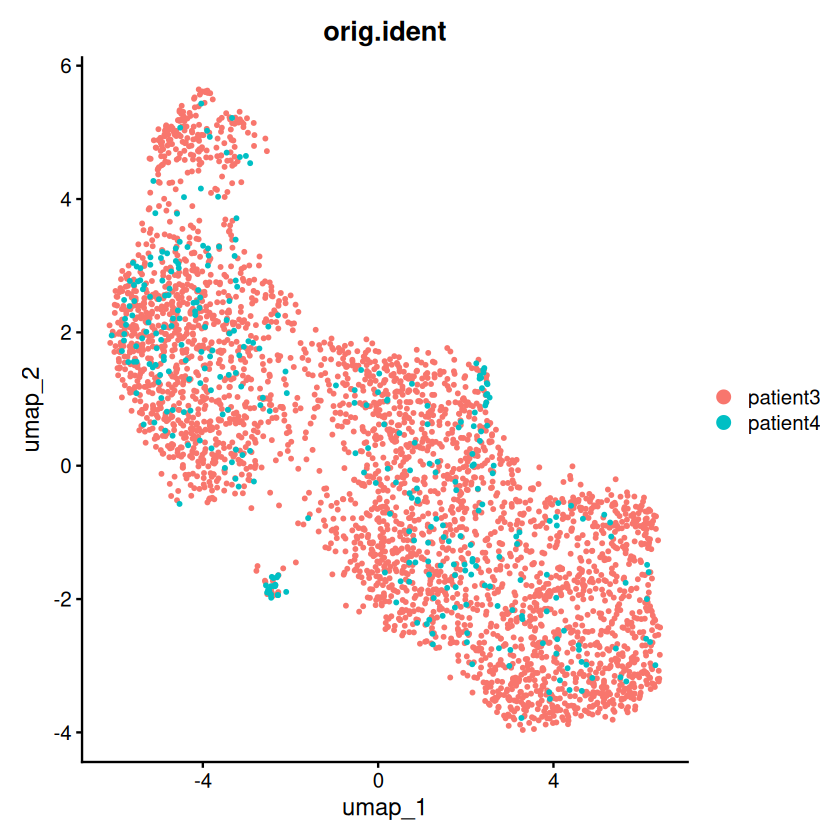

In [182]:
DimPlot(integrated_seurat, reduction = "umap", group.by = "orig.ident")

In [183]:
#head(patient3_transform@meta.data)
#head(patient4_transform@meta.data)

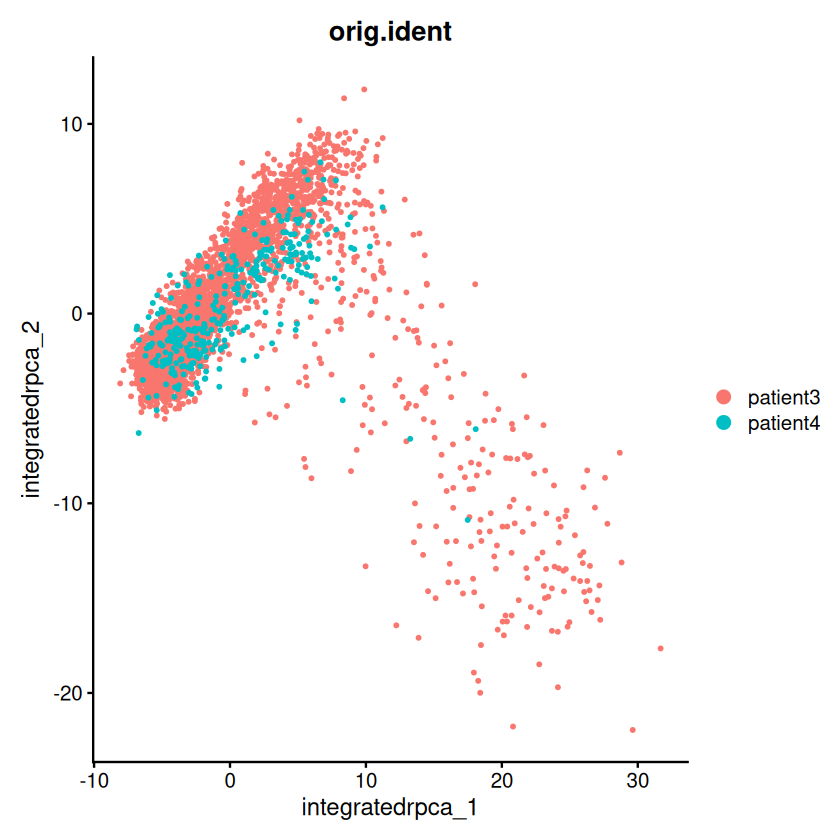

In [184]:
DimPlot(merged_seurat, reduction = "integrated.rpca", group.by = "orig.ident")


--------------------

## 6. scRepertoire on patients 3 and 4 - integrated. data

In [185]:
#' #Getting a sample of a Seurat object
#' scRep_example <- get(data("scRep_example"))
#' 
#' #Using combineExpresion()
#' scRep_example <- combineExpression(combined, scRep_example)

In [186]:
head(S2)
summary(S2)

,cell_id,cell_type_experimental,high_quality_cell,locus,sequence_id,consensus_count,umi_count,sequence,sequence_length,sequence_aa,⋯,fwr3,fwr3_aa,fwr4,fwr4_aa,cdr1,cdr1_aa,cdr2,cdr2_aa,cdr3,cdr3_aa
,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,111840,T_CD8_memory,True,TRA,111840_TRA_1,6529,5,GCAGTGCCAGGCTCATAGGGGCACATGAAGTGTCTACCTTCTGCAGACTACAGTGGCTCAGGAACCGGGGATGCAGTGCCAGGCTCATGGTATCCTGCAGCAGATGTGGGGAGCTTTCCTTCTCTATGTTTCCATGAAGATGGGAGGCACTGCAGGACAAAGCCTTGAGCAGCCCTCTGAAGTGACAGCTGTGGAAGGAGCCATTGTCCAGATAAACTGCACGTACCAGACATCTGGGTTTTATGGGCTGTCCTGGTACCAGCAACATGATGGCGGAGCACCCACATTTCTTTCTTACAATGCTCTGGATGGTTTGGAGGAGACAGGTCGTTTTTCTTCATTCCTTAGTCGCTCTGATAGTTATGGTTACCTCCTTCTACAGGAGCTCCAGATGAAAGACTCTGCCTCTTACTTCTGCGCTGTGAACAACAATGCCAGACTCATGTTTGGAGATGGAACTCAGCTGGTGGTGAAGCCCAATATCCAGAACCCTGACCCTGCCGTGTACCAGCTGAGAGACTCTAAATCCAGTGACAAGTCTGTCTGCCTATTCACCGATTTTGAT,565,QCQAHRGT*SVYLLQTTVAQEPGMQCQAHGILQQMWGAFLLYVSMKMGGTAGQSLEQPSEVTAVEGAIVQINCTYQTSGFYGLSWYQQHDGGAPTFLSYNALDGLEETGRFSSFLSRSDSYGYLLLQELQMKDSASYFCAVNNNARLMFGDGTQLVVKPNIQNPDPAVYQLRDSKSSDKSVCLFTDFD,⋯,GAGGAGACAGGTCGTTTTTCTTCATTCCTTAGTCGCTCTGATAGTTATGGTTACCTCCTTCTACAGGAGCTCCAGATGAAAGACTCTGCCTCTTACTTCTGC,EETGRFSSFLSRSDSYGYLLLQELQMKDSASYFC,TTTGGAGATGGAACTCAGCTGGTGGTGAAGCCC,FGDGTQLVVKP,ACATCTGGGTTTTATGGG,TSGFYG,AATGCTCTGGATGGTTTG,NALDGL,GCTGTGAACAACAATGCCAGACTCATG,AVNNNARLM
2,111840,T_CD8_memory,True,TRB,111840_TRB_1,1130,4,CCCTGTGTCTCCTGGGGGCAGATCATGCAGATACTGGAGTCTCCCAGAACCCCAGACACAAGATCACAAAGAGGGGACAGAATGTAACTTTCAGGTGTGATCCAATTTCTGAACACAACCGCCTTTATTGGTACCGACAGACCCTGGGGCAGGGCCCAGAGTTTCTGACTTACTTCCAGAATGAAGCTCAACTAGAAAAATCAAGGCTGCTCAGTGATCGGTTCTCTGCAGAGAGGCCTAAGGGATCTTTCTCCACCTTGGAGATCCAGCGCACAGAGCAGGGGGACTCGGCCATGTATCTCTGTGCCAGCAGCTTAGTGGGGGGGGGCGGGAATGAGCAGTTCTTCGGGCCAGGGACACGGCTCACCGTGCTAGAGGACCTGAAAAACGTGTTCCCACCCGAGGTCGCTGTGTTTGAGCCATCAGAAGCAGAGATC,437,LCLLGADHADTGVSQNPRHKITKRGQNVTFRCDPISEHNRLYWYRQTLGQGPEFLTYFQNEAQLEKSRLLSDRFSAERPKGSFSTLEIQRTEQGDSAMYLCASSLVGGGGNEQFFGPGTRLTVLEDLKNVFPPEVAVFEPSEAEI,⋯,CTAGAAAAATCAAGGCTGCTCAGTGATCGGTTCTCTGCAGAGAGGCCTAAGGGATCTTTCTCCACCTTGGAGATCCAGCGCACAGAGCAGGGGGACTCGGCCATGTATCTCTGT,LEKSRLLSDRFSAERPKGSFSTLEIQRTEQGDSAMYLC,TTCGGGCCAGGGACACGGCTCACCGTGCTA,FGPGTRLTVL,TCTGAACACAACCGC,SEHNR,TTCCAGAATGAAGCTCAA,FQNEAQ,GCCAGCAGCTTAGTGGGGGGGGGCGGGAATGAGCAGTTC,ASSLVGGGGNEQF
3,146164,T_CD8_memory,True,TRB,146164_TRB_1,13953,6,CCTGCCTGATGCTTATAGGGGGAAGAGGTGGAGACGTTACAGAAACCACCTGGAGCCCCCAGAACTGGCAGACACCTGCCTGATGCTGCCATGGGCCCCCAGCTCCTTGGCTATGTGGTCCTTTGCCTTCTAGGAGCAGGCCCCCTGGAAGCCCAAGTGACCCAGAACCCAAGATACCTCATCACAGTGACTGGAAAGAAGTTAACAGTGACTTGTTCTCAGAATATGAACCATGAGTATATGTCCTGGTATCGACAAGACCCAGGGCTGGGCTTAAGGCAGATCTACTATTCAATGAATGTTGAGGTGACTGATAAGGGAGATGTTCCTGAAGGGTACAAAGTCTCTCGAAAAGAGAAGAGGAATTTCCCCCTGATCCTGGAGTCGCCCAGCCCCAACCAGACCTCTCTGTACTTCTGTGCCAGCAGGCCCCCTAGCACAGATACGCAGTATTTTGGCCCAGGCACCCGGCTGACAGTGCTCGAGGACCTGAAAAACGTGTTCCCACCCGAGGTCGCTGTGTTTGAGCCATCAGAAGCAGAGATC,546,PA*CL*GEEVETLQKPPGAPRTGRHLPDAAMGPQLLGYVVLCLLGAGPLEAQVTQNPRYLITVTGKKLTVTCSQNMNHEYMSWYRQDPGLGLRQIYYSMNVEVTDKGDVPEGYKVSRKEKRNFPLILESPSPNQTSLYFCASRPPSTDTQYFGPGTRLTVLEDLKNVFPPEVAVFEPSEAEI,⋯,ACTGATAAGGGAGATGTTCCTGAAGGGTACAAAGTCTCTCGAAAAGAGAAGAGGAATTTCCCCCTGATCCTGGAGTCGCCCAGCCCCAACCAGACCTCTCTGTACTTCTGT,TDKGDVPEGYKVSRKEKRNFPLILESPSPNQTSLYFC,TTTGGCCCAGGCACCCGGCTGACAGTGCTC,FGPGTRLTVL,ATGAACCATGAGTAT,MNHEY,TCAATGAATGTTGAGGTG,SMNVEV,GCCAGCAGGCCCCCTAGCACAGATACGCAGTAT,ASRPPSTDTQY
4,166368,T_CD8_memory,True,TRA,166368_TRA_1,2183,4,GGGTTTTCGTGATTATAGGGGAAAGCAGATTCTTTTTATGATTTTTAAAGTAGAAATATCCATTCTAGGTGCATTTTTTAAGGGTTTAAAATTTGAATCCTCAGTGAACCAGGGCAGAGAAGAATGATGAAATCCTTGAGAGTTTTACTAGTGATCCTGTGGCTTCAGTTGAGCTGGGTTTGGAGCCAACAGAAGGAGGTGGAGCAGAATTCTGGACCCCTCAGTGTTCCAGAGGGAGCCATTGCCTCTCTCAACTGCACTTACAGTGACCGAGGTTCCCAGTCCTTCTTCTGGTACAGACAATATTCTGGGAAAAGCCCTGAGTTGATAATGTTCATATACTCCAATGGTGACAAAGAAGATGGAAGGTTTACAGCACAGCTCAATAAAGCCAGCCAGTATGTTTCTCTGCTCATCAGAGACTCCCAGCCCAGTGATTCAGCCACCTACCTCTGTGCCGTGACCCCCAATTCCGGGTATGCACTCAACTTCGGCAAAGGCACCTCGCTGTTGGTCACACCCCATATCC

    cell_id         cell_type_experimental high_quality_cell 
 Min.   :  111840   Length:1104            Length:1104       
 1st Qu.:16570333   Class :character       Class :character  
 Median :31420516   Mode  :character       Mode  :character  
 Mean   :29981984                                            
 3rd Qu.:43925625                                            
 Max.   :56566004                                            
                                                             
    locus           sequence_id        consensus_count   umi_count     
 Length:1104        Length:1104        Min.   :    1   Min.   : 1.000  
 Class :character   Class :character   1st Qu.: 1956   1st Qu.: 3.000  
 Mode  :character   Mode  :character   Median : 5085   Median : 6.000  
                                       Mean   : 9861   Mean   : 8.756  
                                       3rd Qu.:12196   3rd Qu.:12.000  
                                       Max.   :74530   Max.   :74.000  


In [187]:
sapply(combined.TCR_p3, nrow)
sapply(combined.TCR_p4, nrow)
sapply(S1, nrow)
sapply(S2, nrow)

P3_S1 
 3532

P4_S1  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA> 
 2471     0     0     0     0     0     0     0

$cell_id
NULL

$cell_type_experimental
NULL

$high_quality_cell
NULL

$locus
NULL

$sequence_id
NULL

$consensus_count
NULL

$umi_count
NULL

$sequence
NULL

$sequence_length
NULL

$sequence_aa
NULL

$sequence_aa_length
NULL

$sequence_alignment
NULL

$sequence_alignment_length
NULL

$sequence_alignment_aa
NULL

$sequence_alignment_aa_length
NULL

$germline_alignment
NULL

$germline_alignment_aa
NULL

$v_germline_alignment
NULL

$v_germline_alignment_aa
NULL

$d_germline_alignment
NULL

$d_germline_alignment_aa
NULL

$j_germline_alignment
NULL

$j_germline_alignment_aa
NULL

$v_germline_start
NULL

$v_germline_end
NULL

$d_germline_start
NULL

$d_germline_end
NULL

$j_germline_start
NULL

$j_germline_end
NULL

$np1_length
NULL

$np2_length
NULL

$junction
NULL

$junction_aa
NULL

$productive
NULL

$rev_comp
NULL

$complete_vdj
NULL

$v_call
NULL

$v_support
NULL

$v_cigar
NULL

$v_sequence_start
NULL

$v_sequence_end
NULL

$d_call
NULL

$d_support
NULL

$d_cigar
NULL

$d_sequence_start
NULL

$d_sequence_end
NULL

$j_call
NULL

$j_support
NULL

$j_cigar
NULL

$j_sequence_start
NULL

$j_sequence_end
NULL

$c_call
NULL

$fwr1
NULL

$fwr1_aa
NULL

$fwr2
NULL

$fwr2_aa
NULL

$fwr3
NULL

$fwr3_aa
NULL

$fwr4
NULL

$fwr4_aa
NULL

$cdr1
NULL

$cdr1_aa
NULL

$cdr2
NULL

$cdr2_aa
NULL

$cdr3
NULL

$cdr3_aa
NULL

$cell_id
NULL

$cell_type_experimental
NULL

$high_quality_cell
NULL

$locus
NULL

$sequence_id
NULL

$consensus_count
NULL

$umi_count
NULL

$sequence
NULL

$sequence_length
NULL

$sequence_aa
NULL

$sequence_aa_length
NULL

$sequence_alignment
NULL

$sequence_alignment_length
NULL

$sequence_alignment_aa
NULL

$sequence_alignment_aa_length
NULL

$germline_alignment
NULL

$germline_alignment_aa
NULL

$v_germline_alignment
NULL

$v_germline_alignment_aa
NULL

$d_germline_alignment
NULL

$d_germline_alignment_aa
NULL

$j_germline_alignment
NULL

$j_germline_alignment_aa
NULL

$v_germline_start
NULL

$v_germline_end
NULL

$d_germline_start
NULL

$d_germline_end
NULL

$j_germline_start
NULL

$j_germline_end
NULL

$np1_length
NULL

$np2_length
NULL

$junction
NULL

$junction_aa
NULL

$productive
NULL

$rev_comp
NULL

$complete_vdj
NULL

$v_call
NULL

$v_support
NULL

$v_cigar
NULL

$v_sequence_start
NULL

$v_sequence_end
NULL

$d_call
NULL

$d_support
NULL

$d_cigar
NULL

$d_sequence_start
NULL

$d_sequence_end
NULL

$j_call
NULL

$j_support
NULL

$j_cigar
NULL

$j_sequence_start
NULL

$j_sequence_end
NULL

$c_call
NULL

$fwr1
NULL

$fwr1_aa
NULL

$fwr2
NULL

$fwr2_aa
NULL

$fwr3
NULL

$fwr3_aa
NULL

$fwr4
NULL

$fwr4_aa
NULL

$cdr1
NULL

$cdr1_aa
NULL

$cdr2
NULL

$cdr2_aa
NULL

$cdr3
NULL

$cdr3_aa
NULL

In [188]:
#combined.TCR_p3 <- combined.TCR_p3[sapply(combined.TCR_p3, nrow) > 0]
#combined.TCR_p4 <- combined.TCR_p4[sapply(combined.TCR_p4, nrow) > 0]

In [189]:
sapply(combined.TCR_p3, nrow)
sapply(combined.TCR_p4, nrow)

P3_S1 
 3532

P4_S1  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA> 
 2471     0     0     0     0     0     0     0

In [190]:
merged_TCR <- combineTCR(
  list(patient3 = combined.TCR_p3, patient4 = combined.TCR_p4),
  samples = c("patient3", "patient4"),
  removeNA = FALSE,
  removeMulti = FALSE,
  filterMulti = FALSE
)

ERROR: Error in (function (..., row.names = NULL, check.rows = FALSE, check.names = TRUE, : arguments imply differing number of rows: 2471, 0


In [ ]:
names(combined.TCR_p3[[1]])
names(combined.TCR_p4[[1]])

In [ ]:
combined.TCR_p3 <- lapply(combined.TCR_p3, function(df) {
  df$chain <- "TRA" 
  return(df)
})

combined.TCR_p4 <- lapply(combined.TCR_p4, function(df) {
  df$chain <- "TRA"
  return(df)
})

In [ ]:
merged_TCR <- combineTCR(
  list(patient3 = combined.TCR_p3, patient4 = combined.TCR_p4),
  samples = c("patient3", "patient4"),
  removeNA = FALSE,
  removeMulti = FALSE,
  filterMulti = FALSE
)

In [ ]:
contig_list_1
contig_list_2

In [ ]:
lapply(contig_list_1, nrow)
lapply(contig_list_2, nrow)

In [ ]:
merged_TCR <- combineTCR(
  list(patient3 = contig_list_1, patient4 = contig_list_2),
  samples = c("patient3", "patient4"),
  removeNA = FALSE,
  removeMulti = FALSE,
  filterMulti = FALSE
)

## combineExpression() on patient 3

In [ ]:
head(combined.TCR_p3[[1]]$barcode)

In [ ]:
rownames(patient3_transform@meta.data)

In [ ]:
# Matching the barcodes
combined.TCR_p3 <- lapply(combined.TCR_p3, function(x) {
  x$barcode <- gsub("P3_S1_", "", x$barcode)
  return(x)
})

In [ ]:
# checking metadata first
head(colnames(patient3_transform@meta.data))
colnames(combined.TCR_p3[[1]])
# Check barcodes in the TCR object (first list element)
head(combined.TCR_p3[[1]]$barcode, 10)  # Just the first 10 barcodes
barcodes_tcr <- unlist(lapply(combined.TCR_p3, function(x) x$barcode))
head(barcodes_tcr, 10)
# These are the cell names (barcodes) from the Seurat object
barcodes_seurat <- colnames(patient3_transform)
head(barcodes_seurat, 10)

In [ ]:
#patient3_transform$orig.ident <- as.character(patient3_transform$orig.ident)

In [ ]:
sce <- combineExpression(
  combined.TCR_p3,
  patient3_transform,
  cloneCall = "CTgene",
  group.by = "sample",
  proportion = TRUE,
  cloneSize = c(Single = 1, Small = 5, Medium = 20, Large = 100, Hyperexpanded = 500)
)

In [ ]:
sce
colnames(sce@meta.data)

## combineExpression() on patient 4